In [1]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, EsmForMaskedLM
from tokenizers import Tokenizer
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

from collections import Counter


/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from scipy.spatial.distance import jensenshannon

In [3]:
from plm_compare_progen2 import *
from protein_data import *

All wild types from protein gym. The ones with length $\leq 1024$ have non None ouputs from ProGen2.

In [4]:
with open('//Users/johnhutchens/Desktop/Practicum/Data/Wild_Dictionaries/pg2_wild_types_matrices.pickle',
           'rb') as f:
    pg_dict = pickle.load(f)

In [5]:
keys = list(pg_dict.keys())


In [6]:
list(pg_dict[keys[0]].keys())

['sequence', 'DMS', 'log_probs', 'ref_log_probs', 'llr_matrix', 'mut_poss']

In [12]:
All_non_uniform=[]
unif_dist = np.ones(20)/20
for k in keys:
    unif_dist = np.ones(20)/20
    non_uniform = []



    print(k)
    mut_poss = pg_dict[k]['mut_poss']
    m_list = []
    for mp in mut_poss:
        mut_list = mp.split(":")
        
        for x in mut_list:
            mut = x
            len_mut = len(mut)
            orig = mut[0]
            pos = int(mut[1:len_mut-1])-1
            new = mut[len_mut-1]
            m_list.append(pos)

    counts_m_list = Counter(m_list)
    m_list_count_dict = dict(counts_m_list)
    print(m_list_count_dict)
    print(list(m_list_count_dict.keys()))
    log_probs = pg_dict[k]['log_probs']
    if log_probs is not None:
        #print(log_probs[0])
        for i in range(len(log_probs)):
            prob_dist = np.array(torch.exp(log_probs[i]), dtype=float, copy=True)
            # print(jensenshannon(prob_dist, unif_dist))
            if jensenshannon(prob_dist, unif_dist) > 0.3:
                non_uniform.append(i)
                All_non_uniform.append(i)
        print(non_uniform)
        print('=====================================================================')


SDA_BACSU
{15: 19, 23: 19, 5: 991, 31: 989, 34: 985, 35: 983, 10: 19, 17: 19, 26: 19, 29: 19, 6: 19, 13: 19, 24: 19, 38: 19, 39: 19, 9: 19, 25: 19, 28: 19, 32: 19, 40: 19, 41: 19, 14: 19, 33: 19, 2: 19, 20: 19, 27: 19, 37: 19, 3: 19, 7: 19, 8: 19, 18: 19, 0: 19, 19: 19, 21: 18, 30: 19, 22: 19, 1: 19, 11: 19, 36: 18, 42: 19, 4: 19, 16: 19, 43: 19, 12: 19}
[15, 23, 5, 31, 34, 35, 10, 17, 26, 29, 6, 13, 24, 38, 39, 9, 25, 28, 32, 40, 41, 14, 33, 2, 20, 27, 37, 3, 7, 8, 18, 0, 19, 21, 30, 22, 1, 11, 36, 42, 4, 16, 43, 12]
[25, 28, 31, 32, 35, 36]
PAI1_HUMAN
{118: 12, 154: 14, 178: 13, 190: 13, 225: 12, 260: 12, 261: 13, 271: 13, 278: 12, 326: 14, 31: 14, 340: 11, 342: 14, 357: 12, 34: 10, 362: 13, 367: 13, 370: 13, 46: 13, 48: 12, 62: 12, 66: 14, 82: 12, 83: 13, 94: 14, 96: 13, 111: 17, 117: 16, 124: 15, 147: 14, 160: 14, 180: 16, 203: 16, 215: 15, 239: 17, 244: 16, 253: 14, 307: 14, 319: 15, 327: 15, 333: 15, 377: 15, 36: 13, 51: 15, 89: 16, 90: 12, 103: 14, 112: 15, 150: 14, 152: 14, 234

/var/folders/30/5r4_75_n4bz34nyphw8tfv3m0000gn/T/ipykernel_5064/4038100233.py:31: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prob_dist = np.array(torch.exp(log_probs[i]), dtype=float, copy=True)


{5: 640, 6: 42387, 7: 39247, 10: 43224, 19: 28670, 20: 32330, 23: 44825, 8: 44329, 21: 43155, 18: 40224, 22: 25079, 9: 578, 11: 201, 14: 41, 17: 491, 15: 253, 12: 199, 13: 5, 16: 8, 24: 188, 49: 18, 51: 23, 52: 11, 54: 15, 53: 23, 55: 41688, 58: 29594, 59: 31392, 75: 29397, 76: 25624, 77: 47688, 78: 34305, 80: 44136, 81: 44072, 84: 25807, 79: 30379, 61: 34722, 83: 307, 73: 295, 63: 252, 66: 12621, 71: 335, 74: 237, 72: 12421, 82: 321, 70: 106, 68: 270, 67: 337, 69: 416, 65: 13825, 62: 184, 64: 65, 56: 322, 57: 248, 60: 66, 86: 8202, 91: 8450, 92: 13829, 85: 13865, 94: 134, 87: 104, 93: 52, 88: 153, 89: 79, 90: 58, 95: 46975, 97: 36069, 98: 45061, 104: 50652, 115: 520, 118: 47946, 119: 32209, 120: 30584, 121: 32210, 123: 282, 116: 30499, 101: 48323, 103: 27215, 117: 458, 111: 227, 102: 526, 99: 171, 124: 487, 109: 197, 110: 138, 113: 112, 122: 477, 105: 96, 106: 125, 100: 610, 112: 112, 107: 64, 108: 81, 96: 33341, 114: 18, 135: 296, 136: 60875, 138: 39028, 142: 64353, 143: 67799, 156: 

In [18]:
unif_dist = np.ones(20)/20
keys = list(pg_dict.keys())

In [21]:
j = 5
k=keys[j]
ACE2_non_uniform03 = []

print(k)
mut_poss = pg_dict[k]['mut_poss']
m_list = []
for mp in mut_poss:
    mut_list = mp.split(":")
    
    for x in mut_list:
        mut = x
        len_mut = len(mut)
        orig = mut[0]
        pos = int(mut[1:len_mut-1])-1
        new = mut[len_mut-1]
        m_list.append(pos)

counts_m_list = Counter(m_list)
m_list_count_dict = dict(counts_m_list)
print(m_list_count_dict)
print(list(m_list_count_dict.keys()))
log_probs = pg_dict[k]['log_probs']
if log_probs is not None:
    #print(log_probs[0])
    for i in range(len(log_probs)):
        prob_dist = np.array(torch.exp(log_probs[i]), dtype=float, copy=True)
        # print(jensenshannon(prob_dist, unif_dist))
        if jensenshannon(prob_dist, unif_dist) > 0.3:
            ACE2_non_uniform03.append(i)

ACE2_HUMAN
{24: 19, 385: 19, 386: 19, 45: 19, 64: 19, 70: 19, 29: 19, 349: 19, 354: 19, 366: 19, 381: 19, 37: 19, 508: 19, 66: 19, 21: 19, 22: 19, 328: 19, 34: 19, 36: 19, 397: 19, 401: 19, 405: 19, 55: 19, 56: 19, 74: 19, 273: 19, 27: 19, 355: 19, 389: 19, 39: 19, 437: 19, 503: 19, 511: 19, 71: 19, 325: 19, 351: 19, 353: 19, 344: 19, 33: 19, 373: 19, 377: 19, 400: 19, 504: 19, 20: 19, 445: 19, 53: 19, 25: 19, 30: 19, 352: 19, 440: 19, 67: 19, 73: 19, 28: 19, 350: 19, 369: 19, 38: 19, 44: 19, 72: 19, 78: 19, 90: 19, 94: 19, 365: 19, 382: 19, 61: 19, 81: 19, 276: 19, 289: 19, 329: 19, 32: 19, 393: 19, 48: 19, 50: 19, 60: 19, 62: 19, 63: 19, 89: 19, 345: 19, 388: 19, 83: 19, 101: 19, 23: 19, 324: 19, 387: 19, 41: 19, 441: 19, 59: 19, 75: 19, 88: 19, 95: 19, 97: 19, 272: 19, 356: 19, 392: 19, 513: 19, 517: 19, 18: 19, 408: 19, 510: 19, 19: 19, 275: 19, 26: 19, 323: 19, 346: 19, 370: 19, 444: 19, 91: 19, 342: 19, 58: 19, 92: 19, 348: 19, 47: 19, 68: 19, 40: 19, 49: 19, 509: 19, 514: 19, 82

/var/folders/30/5r4_75_n4bz34nyphw8tfv3m0000gn/T/ipykernel_5064/987718114.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prob_dist = np.array(torch.exp(log_probs[i]), dtype=float, copy=True)


In [22]:
j = 5
k=keys[j]
ACE2_non_uniform05 = []

print(k)
mut_poss = pg_dict[k]['mut_poss']
m_list = []
for mp in mut_poss:
    mut_list = mp.split(":")
    
    for x in mut_list:
        mut = x
        len_mut = len(mut)
        orig = mut[0]
        pos = int(mut[1:len_mut-1])-1
        new = mut[len_mut-1]
        m_list.append(pos)

counts_m_list = Counter(m_list)
m_list_count_dict = dict(counts_m_list)
print(m_list_count_dict)
print(list(m_list_count_dict.keys()))
log_probs = pg_dict[k]['log_probs']
if log_probs is not None:
    #print(log_probs[0])
    for i in range(len(log_probs)):
        prob_dist = np.array(torch.exp(log_probs[i]), dtype=float, copy=True)
        # print(jensenshannon(prob_dist, unif_dist))
        if jensenshannon(prob_dist, unif_dist) > 0.5:
            ACE2_non_uniform05.append(i)

ACE2_HUMAN
{24: 19, 385: 19, 386: 19, 45: 19, 64: 19, 70: 19, 29: 19, 349: 19, 354: 19, 366: 19, 381: 19, 37: 19, 508: 19, 66: 19, 21: 19, 22: 19, 328: 19, 34: 19, 36: 19, 397: 19, 401: 19, 405: 19, 55: 19, 56: 19, 74: 19, 273: 19, 27: 19, 355: 19, 389: 19, 39: 19, 437: 19, 503: 19, 511: 19, 71: 19, 325: 19, 351: 19, 353: 19, 344: 19, 33: 19, 373: 19, 377: 19, 400: 19, 504: 19, 20: 19, 445: 19, 53: 19, 25: 19, 30: 19, 352: 19, 440: 19, 67: 19, 73: 19, 28: 19, 350: 19, 369: 19, 38: 19, 44: 19, 72: 19, 78: 19, 90: 19, 94: 19, 365: 19, 382: 19, 61: 19, 81: 19, 276: 19, 289: 19, 329: 19, 32: 19, 393: 19, 48: 19, 50: 19, 60: 19, 62: 19, 63: 19, 89: 19, 345: 19, 388: 19, 83: 19, 101: 19, 23: 19, 324: 19, 387: 19, 41: 19, 441: 19, 59: 19, 75: 19, 88: 19, 95: 19, 97: 19, 272: 19, 356: 19, 392: 19, 513: 19, 517: 19, 18: 19, 408: 19, 510: 19, 19: 19, 275: 19, 26: 19, 323: 19, 346: 19, 370: 19, 444: 19, 91: 19, 342: 19, 58: 19, 92: 19, 348: 19, 47: 19, 68: 19, 40: 19, 49: 19, 509: 19, 514: 19, 82

/var/folders/30/5r4_75_n4bz34nyphw8tfv3m0000gn/T/ipykernel_5064/2989871641.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prob_dist = np.array(torch.exp(log_probs[i]), dtype=float, copy=True)


In [ ]:
j = 5
k=keys[j]
ACE2_non_uniform06 = []

print(k)
mut_poss = pg_dict[k]['mut_poss']
m_list = []
for mp in mut_poss:
    mut_list = mp.split(":")
    
    for x in mut_list:
        mut = x
        len_mut = len(mut)
        orig = mut[0]
        pos = int(mut[1:len_mut-1])-1
        new = mut[len_mut-1]
        m_list.append(pos)

counts_m_list = Counter(m_list)
m_list_count_dict = dict(counts_m_list)
print(m_list_count_dict)
print(list(m_list_count_dict.keys()))
log_probs = pg_dict[k]['log_probs']
if log_probs is not None:
    #print(log_probs[0])
    for i in range(len(log_probs)):
        prob_dist = np.array(torch.exp(log_probs[i]), dtype=float, copy=True)
        print(jensenshannon(prob_dist, unif_dist))
        if jensenshannon(prob_dist, unif_dist) > 0.6:
            ACE2_non_uniform06.append(i)

ACE2_HUMAN
{24: 19, 385: 19, 386: 19, 45: 19, 64: 19, 70: 19, 29: 19, 349: 19, 354: 19, 366: 19, 381: 19, 37: 19, 508: 19, 66: 19, 21: 19, 22: 19, 328: 19, 34: 19, 36: 19, 397: 19, 401: 19, 405: 19, 55: 19, 56: 19, 74: 19, 273: 19, 27: 19, 355: 19, 389: 19, 39: 19, 437: 19, 503: 19, 511: 19, 71: 19, 325: 19, 351: 19, 353: 19, 344: 19, 33: 19, 373: 19, 377: 19, 400: 19, 504: 19, 20: 19, 445: 19, 53: 19, 25: 19, 30: 19, 352: 19, 440: 19, 67: 19, 73: 19, 28: 19, 350: 19, 369: 19, 38: 19, 44: 19, 72: 19, 78: 19, 90: 19, 94: 19, 365: 19, 382: 19, 61: 19, 81: 19, 276: 19, 289: 19, 329: 19, 32: 19, 393: 19, 48: 19, 50: 19, 60: 19, 62: 19, 63: 19, 89: 19, 345: 19, 388: 19, 83: 19, 101: 19, 23: 19, 324: 19, 387: 19, 41: 19, 441: 19, 59: 19, 75: 19, 88: 19, 95: 19, 97: 19, 272: 19, 356: 19, 392: 19, 513: 19, 517: 19, 18: 19, 408: 19, 510: 19, 19: 19, 275: 19, 26: 19, 323: 19, 346: 19, 370: 19, 444: 19, 91: 19, 342: 19, 58: 19, 92: 19, 348: 19, 47: 19, 68: 19, 40: 19, 49: 19, 509: 19, 514: 19, 82

/var/folders/30/5r4_75_n4bz34nyphw8tfv3m0000gn/T/ipykernel_5064/125765746.py:27: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prob_dist = np.array(torch.exp(log_probs[i]), dtype=float, copy=True)


In [7]:
j = 5
k=keys[j]
len(pg_dict[k]['sequence'])

805

In [13]:
mut_poss = pg_dict[k]['mut_poss']
m_list = []
for mp in mut_poss:
    mut_list = mp.split(":")
    
    for x in mut_list:
        mut = x
        len_mut = len(mut)
        orig = mut[0]
        pos = int(mut[1:len_mut-1])-1
        new = mut[len_mut-1]
        m_list.append(pos)

counts_m_list = Counter(m_list)
m_list_count_dict = dict(counts_m_list)
m_poss = sorted(list(m_list_count_dict.keys()))
print(m_list_count_dict)
print(m_poss)

{24: 19, 385: 19, 386: 19, 45: 19, 64: 19, 70: 19, 29: 19, 349: 19, 354: 19, 366: 19, 381: 19, 37: 19, 508: 19, 66: 19, 21: 19, 22: 19, 328: 19, 34: 19, 36: 19, 397: 19, 401: 19, 405: 19, 55: 19, 56: 19, 74: 19, 273: 19, 27: 19, 355: 19, 389: 19, 39: 19, 437: 19, 503: 19, 511: 19, 71: 19, 325: 19, 351: 19, 353: 19, 344: 19, 33: 19, 373: 19, 377: 19, 400: 19, 504: 19, 20: 19, 445: 19, 53: 19, 25: 19, 30: 19, 352: 19, 440: 19, 67: 19, 73: 19, 28: 19, 350: 19, 369: 19, 38: 19, 44: 19, 72: 19, 78: 19, 90: 19, 94: 19, 365: 19, 382: 19, 61: 19, 81: 19, 276: 19, 289: 19, 329: 19, 32: 19, 393: 19, 48: 19, 50: 19, 60: 19, 62: 19, 63: 19, 89: 19, 345: 19, 388: 19, 83: 19, 101: 19, 23: 19, 324: 19, 387: 19, 41: 19, 441: 19, 59: 19, 75: 19, 88: 19, 95: 19, 97: 19, 272: 19, 356: 19, 392: 19, 513: 19, 517: 19, 18: 19, 408: 19, 510: 19, 19: 19, 275: 19, 26: 19, 323: 19, 346: 19, 370: 19, 444: 19, 91: 19, 342: 19, 58: 19, 92: 19, 348: 19, 47: 19, 68: 19, 40: 19, 49: 19, 509: 19, 514: 19, 82: 19}
[18, 

# ACE2_HUMAN

In [40]:
j = 5
k=keys[j]
print(k)
seq = pg_dict[k]['sequence']
print(seq)
log_probs = pg_dict[k]['log_probs']
elog_probs = torch.exp(log_probs)

list03 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.3)
list05 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.5)
list06 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.6)
m_poss = sorted(list(m_list_count_dict.keys()))


ACE2_HUMAN
MSSSSWLLLSLVAVTAAQSTIEEQAKTFLDKFNHEAEDLFYQSSLASWNYNTNITEENVQNMNNAGDKWSAFLKEQSTLAQMYPLQEIQNLTVKLQLQALQQNGSSVLSEDKSKRLNTILNTMSTIYSTGKVCNPDNPQECLLLEPGLNEIMANSLDYNERLWAWESWRSEVGKQLRPLYEEYVVLKNEMARANHYEDYGDYWRGDYEVNGVDGYDYSRGQLIEDVEHTFEEIKPLYEHLHAYVRAKLMNAYPSYISPIGCLPAHLLGDMWGRFWTNLYSLTVPFGQKPNIDVTDAMVDQAWDAQRIFKEAEKFFVSVGLPNMTQGFWENSMLTDPGNVQKAVCHPTAWDLGKGDFRILMCTKVTMDDFLTAHHEMGHIQYDMAYAAQPFLLRNGANEGFHEAVGEIMSLSAATPKHLKSIGLLSPDFQEDNETEINFLLKQALTIVGTLPFTYMLEKWRWMVFKGEIPKDQWMKKWWEMKREIVGVVEPVPHDETYCDPASLFHVSNDYSFIRYYTRTLYQFQFQEALCQAAKHEGPLHKCDISNSTEAGQKLFNMLRLGKSEPWTLALENVVGAKNMNVRPLLNYFEPLFTWLKDQNKNSFVGWSTDWSPYADQSIKVRISLKSALGDKAYEWNDNEMYLFRSSVAYAMRQYFLKVKNQMILFGEEDVRVANLKPRISFNFFVTAPKNVSDIIPRTEVEKAIRMSRSRINDAFRLNDNSLEFLGIQPTLGPPNQPPVSIWLIVFGVVMGVIVVGIVILIFTGIRDRKKKNKARSGENPYASIDISKGENNPGFQNTDDVQTSF


In [30]:
print(list05)
print(m_poss)

[25, 28, 29, 51, 52, 55, 104, 116, 126, 127, 128, 129, 145, 146, 149, 151, 154, 155, 161, 168, 172, 176, 179, 183, 187, 190, 194, 197, 200, 202, 222, 226, 229, 231, 233, 234, 235, 236, 240, 244, 245, 252, 260, 262, 263, 264, 266, 267, 268, 270, 274, 276, 278, 281, 290, 292, 293, 294, 296, 297, 299, 300, 307, 310, 311, 312, 314, 315, 316, 317, 318, 320, 327, 330, 332, 342, 343, 344, 345, 346, 347, 349, 354, 355, 359, 360, 361, 362, 364, 365, 367, 369, 371, 373, 374, 375, 377, 378, 380, 381, 383, 384, 385, 388, 391, 392, 394, 395, 397, 399, 400, 401, 402, 403, 404, 405, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 423, 430, 431, 433, 435, 438, 439, 440, 441, 442, 443, 446, 447, 448, 449, 451, 452, 455, 456, 457, 458, 459, 460, 462, 463, 465, 467, 476, 477, 480, 481, 484, 485, 488, 489, 490, 494, 496, 498, 499, 500, 501, 502, 503, 504, 505, 507, 508, 509, 511, 512, 513, 514, 515, 516, 519, 520, 521, 522, 523, 524, 525, 527, 528, 532, 538, 541, 542, 543, 546, 549, 550, 553, 

805


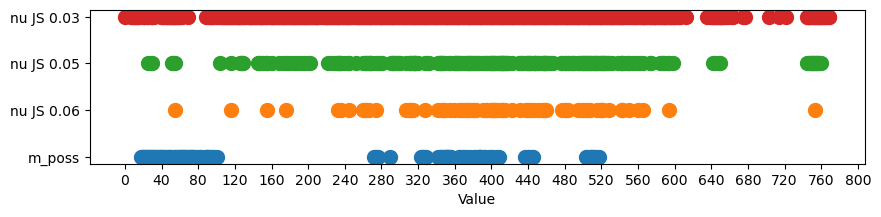

In [ ]:
lists = [m_poss, list06, list05, list03]

m = len(seq)
print(m)

plt.figure(figsize=(10,2))

# Plot each list at a different height
for i, lst in enumerate(lists):
    y_height = i + 1
    plt.scatter(lst, [y_height]*len(lst), s=100, label=f'List {i+1}')

plt.yticks([1,2,3,4], ['m_poss', 'nu JS 0.6', 'nu JS 0.5','nu JS 0.3'])
plt.xticks(range(0,m, m//20))
plt.xlabel('Value')
plt.title('')
#plt.legend()
plt.show()


# RDRP_I33A0

In [49]:
j = 6
k=keys[j]
print(k)
mut_poss = pg_dict[k]['mut_poss']
m_list = []
for mp in mut_poss:
    mut_list = mp.split(":")
    
    for x in mut_list:
        mut = x
        len_mut = len(mut)
        orig = mut[0]
        pos = int(mut[1:len_mut-1])-1
        new = mut[len_mut-1]
        m_list.append(pos)

counts_m_list = Counter(m_list)
m_list_count_dict = dict(counts_m_list)
m_poss = sorted(list(m_list_count_dict.keys()))
print(m_list_count_dict)
print(m_poss)

seq = pg_dict[k]['sequence']
print(seq)
print(len(seq))
log_probs = pg_dict[k]['log_probs']
elog_probs = torch.exp(log_probs)

list03 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.3)
list05 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.5)
list07 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.7)
m_poss = sorted(list(m_list_count_dict.keys()))

RDRP_I33A0
{138: 15, 139: 15, 141: 14, 143: 15, 13: 14, 156: 11, 16: 17, 220: 16, 230: 16, 239: 15, 241: 15, 258: 17, 279: 12, 282: 14, 319: 14, 339: 13, 348: 12, 369: 13, 373: 11, 400: 14, 447: 15, 452: 13, 460: 15, 502: 9, 520: 15, 541: 17, 543: 15, 546: 14, 586: 15, 62: 15, 642: 16, 647: 15, 651: 14, 658: 10, 660: 12, 716: 15, 721: 16, 725: 16, 82: 14, 90: 15, 92: 12, 106: 17, 262: 18, 469: 7, 560: 17, 609: 15, 624: 16, 691: 15, 692: 14, 746: 17, 86: 18, 119: 14, 129: 18, 164: 17, 168: 16, 192: 15, 229: 17, 26: 17, 294: 13, 1: 19, 304: 17, 376: 14, 382: 9, 397: 16, 40: 16, 438: 16, 444: 15, 445: 16, 521: 17, 537: 18, 553: 17, 564: 13, 592: 9, 616: 17, 618: 17, 635: 17, 657: 16, 684: 17, 69: 17, 724: 18, 728: 18, 75: 17, 85: 16, 103: 15, 108: 16, 111: 17, 147: 13, 158: 18, 171: 17, 176: 18, 177: 18, 179: 16, 231: 16, 255: 17, 263: 17, 266: 18, 276: 16, 296: 18, 310: 17, 330: 16, 357: 14, 370: 15, 389: 16, 456: 16, 490: 19, 507: 15, 518: 16, 50: 17, 574: 5, 580: 16, 607: 19, 59: 18, 6

757


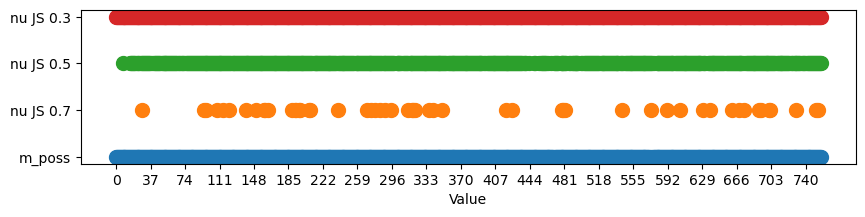

In [50]:
lists = [m_poss, list07, list05, list03]

m = len(seq)
print(m)

plt.figure(figsize=(10,2))

# Plot each list at a different height
for i, lst in enumerate(lists):
    y_height = i + 1
    plt.scatter(lst, [y_height]*len(lst), s=100, label=f'List {i+1}')

plt.yticks([1,2,3,4], ['m_poss', 'nu JS 0.7', 'nu JS 0.5','nu JS 0.3'])
plt.xticks(range(0,m, m//20))
plt.xlabel('Value')
plt.title('')
#plt.legend()
plt.show()


# RAD_ANTMA

RAD_ANTMA
{12: 5, 14: 18, 25: 19, 28: 6, 30: 17, 3: 19, 8: 17, 17: 19, 19: 19, 22: 14, 49: 19, 10: 17, 32: 19, 37: 18, 38: 47, 44: 18, 48: 19, 5: 87, 34: 126, 35: 47, 9: 7, 33: 17, 42: 12, 45: 18, 50: 19, 53: 19, 18: 19, 40: 15, 41: 18, 51: 18, 4: 19, 7: 18, 13: 5, 46: 18, 26: 17, 6: 18, 0: 18, 21: 19, 36: 19, 11: 18, 23: 9, 29: 18, 2: 15, 20: 18, 15: 17, 27: 4, 31: 7, 39: 4, 47: 19, 24: 3, 1: 6, 16: 5, 43: 5, 52: 19}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
PWSAKENKAFERALAVYDKDTPDRWANVARAVEGRTPEEVKKHYEILVEDIKYI
54
54


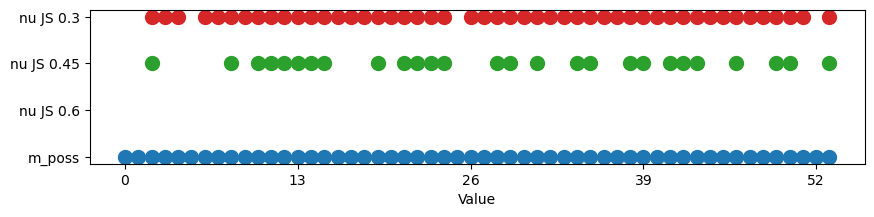

In [51]:
j = 20
k=keys[j]
print(k)

mut_poss = pg_dict[k]['mut_poss']
m_list = []
for mp in mut_poss:
    mut_list = mp.split(":")
    
    for x in mut_list:
        mut = x
        len_mut = len(mut)
        orig = mut[0]
        pos = int(mut[1:len_mut-1])-1
        new = mut[len_mut-1]
        m_list.append(pos)

counts_m_list = Counter(m_list)
m_list_count_dict = dict(counts_m_list)
m_poss = sorted(list(m_list_count_dict.keys()))
print(m_list_count_dict)
print(m_poss)

seq = pg_dict[k]['sequence']
print(seq)
print(len(seq))
log_probs = pg_dict[k]['log_probs']
elog_probs = torch.exp(log_probs)

list03 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.3)
list045 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.45)
list06 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.7)
m_poss = sorted(list(m_list_count_dict.keys()))

lists = [m_poss, list06, list045, list03]

m = len(seq)
print(m)

plt.figure(figsize=(10,2))

# Plot each list at a different height
for i, lst in enumerate(lists):
    y_height = i + 1
    plt.scatter(lst, [y_height]*len(lst), s=100, label=f'List {i+1}')

plt.yticks([1,2,3,4], ['m_poss', 'nu JS 0.6', 'nu JS 0.45','nu JS 0.3'])
plt.xticks(range(0,m, m//4))
plt.xlabel('Value')
plt.title('')
#plt.legend()
plt.show()

P53_HUMAN
{101: 1, 103: 2, 104: 6, 105: 2, 106: 3, 107: 3, 108: 4, 109: 6, 110: 4, 111: 2, 112: 6, 113: 1, 114: 1, 115: 3, 116: 2, 117: 3, 118: 3, 119: 5, 120: 2, 121: 1, 122: 2, 123: 5, 124: 5, 125: 7, 126: 5, 127: 4, 128: 4, 129: 6, 130: 7, 131: 7, 132: 6, 133: 5, 134: 7, 135: 6, 136: 4, 137: 5, 138: 5, 139: 5, 140: 7, 141: 7, 142: 5, 143: 5, 144: 5, 145: 5, 146: 6, 147: 7, 148: 4, 149: 6, 150: 5, 151: 6, 152: 7, 153: 6, 154: 6, 155: 6, 156: 5, 157: 9, 158: 7, 159: 6, 160: 7, 161: 6, 162: 6, 163: 6, 164: 5, 165: 5, 166: 5, 167: 8, 168: 4, 169: 6, 170: 6, 171: 5, 172: 6, 173: 6, 174: 7, 175: 6, 176: 8, 177: 7, 178: 7, 179: 6, 180: 6, 181: 3, 182: 2, 183: 6, 184: 6, 185: 6, 186: 6, 187: 2, 188: 6, 189: 6, 190: 5, 191: 5, 192: 7, 193: 6, 194: 7, 195: 5, 196: 5, 197: 5, 198: 5, 199: 6, 200: 3, 201: 6, 202: 5, 203: 6, 204: 6, 205: 2, 206: 7, 207: 7, 208: 4, 209: 7, 210: 5, 211: 5, 212: 5, 213: 5, 214: 7, 215: 6, 216: 6, 217: 5, 218: 6, 219: 6, 220: 5, 221: 6, 222: 6, 223: 4, 224: 6, 225: 

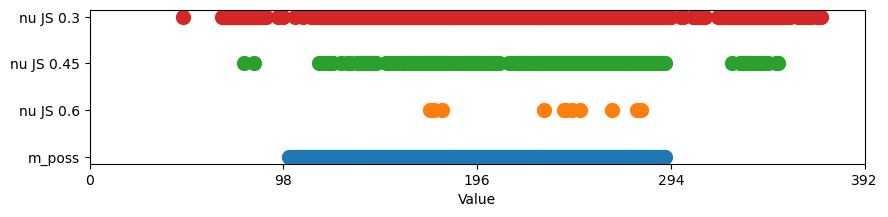

In [56]:
j = 30
k=keys[j]
print(k)

mut_poss = pg_dict[k]['mut_poss']
m_list = []
for mp in mut_poss:
    mut_list = mp.split(":")
    
    for x in mut_list:
        mut = x
        len_mut = len(mut)
        orig = mut[0]
        pos = int(mut[1:len_mut-1])-1
        new = mut[len_mut-1]
        m_list.append(pos)

counts_m_list = Counter(m_list)
m_list_count_dict = dict(counts_m_list)
m_poss = sorted(list(m_list_count_dict.keys()))
print(m_list_count_dict)
print(m_poss)

seq = pg_dict[k]['sequence']
print(seq)
print(len(seq))
log_probs = pg_dict[k]['log_probs']
elog_probs = torch.exp(log_probs)

list03 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.3)
list045 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.45)
list06 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.7)
m_poss = sorted(list(m_list_count_dict.keys()))

lists = [m_poss, list06, list045, list03]

m = len(seq)
print(m)

plt.figure(figsize=(10,2))

# Plot each list at a different height
for i, lst in enumerate(lists):
    y_height = i + 1
    plt.scatter(lst, [y_height]*len(lst), s=100, label=f'List {i+1}')

plt.yticks([1,2,3,4], ['m_poss', 'nu JS 0.6', 'nu JS 0.45','nu JS 0.3'])
plt.xticks(range(0,m, m//4))
plt.xlabel('Value')
plt.title('')
#plt.legend()
plt.show()

# RL40A_YEAST

RL40A_YEAST
{1: 12, 2: 17, 3: 16, 4: 14, 5: 18, 6: 18, 7: 18, 8: 19, 9: 16, 10: 19, 11: 8, 12: 19, 13: 17, 14: 17, 15: 18, 16: 19, 17: 19, 18: 19, 19: 19, 20: 17, 21: 7, 22: 17, 23: 19, 24: 19, 25: 10, 26: 16, 27: 19, 28: 17, 29: 13, 30: 18, 31: 18, 32: 19, 33: 18, 34: 19, 35: 16, 36: 19, 37: 19, 38: 17, 39: 17, 40: 18, 41: 19, 42: 11, 43: 19, 44: 19, 45: 19, 46: 13, 47: 19, 48: 9, 49: 12, 50: 18, 51: 19, 52: 19, 53: 17, 54: 19, 55: 14, 56: 19, 57: 17, 58: 12, 59: 18, 60: 19, 61: 19, 62: 19, 63: 19, 64: 19, 65: 18, 66: 18, 67: 15, 68: 19, 69: 15, 70: 14, 71: 19, 72: 12, 73: 13, 74: 17, 75: 12}
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75]
MQIFVKTLTGKTITLEVESSDTIDNVKSKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGGIIEPSLKALASKYNCDKSVCRKCYARLPPRA

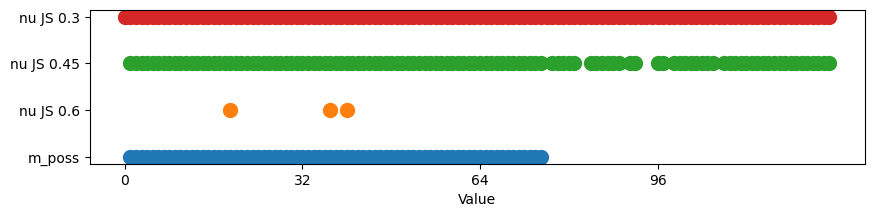

In [63]:
j = 8
k=keys[j]
print(k)

mut_poss = pg_dict[k]['mut_poss']
m_list = []
for mp in mut_poss:
    mut_list = mp.split(":")
    
    for x in mut_list:
        mut = x
        len_mut = len(mut)
        orig = mut[0]
        pos = int(mut[1:len_mut-1])-1
        new = mut[len_mut-1]
        m_list.append(pos)

counts_m_list = Counter(m_list)
m_list_count_dict = dict(counts_m_list)
m_poss = sorted(list(m_list_count_dict.keys()))
print(m_list_count_dict)
print(m_poss)

seq = pg_dict[k]['sequence']
print(seq)
print(len(seq))
log_probs = pg_dict[k]['log_probs']
elog_probs = torch.exp(log_probs)

list03 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.3)
list045 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.45)
list06 = js_non_prob_list(elog_probs,prob_dist2=np.ones(20)/20, threshold=0.7)
m_poss = sorted(list(m_list_count_dict.keys()))

lists = [m_poss, list06, list045, list03]

m = len(seq)
print(m)

plt.figure(figsize=(10,2))

# Plot each list at a different height
for i, lst in enumerate(lists):
    y_height = i + 1
    plt.scatter(lst, [y_height]*len(lst), s=100, label=f'List {i+1}')

plt.yticks([1,2,3,4], ['m_poss', 'nu JS 0.6', 'nu JS 0.45','nu JS 0.3'])
plt.xticks(range(0,m, m//4))
plt.xlabel('Value')
plt.title('')
#plt.legend()
plt.show()